Name: Megan Huy

Project: Detect Fake and Real Instagram Accounts

## Objective ##
-Develop an ML model to classify Instagram accounts as fake or real.

-Optimize for accuracy, sensitivity, and specificity while reducing cost.

-Deploy the model for scalability and cost efficiency.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score, roc_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## Instagram Data ##

In [2]:
#Import Train and Test Data
train_data = pd.read_csv("C:/Users/Megan Huy/Documents/Instagram Project/instagram-data-train.csv") 
test_data = pd.read_csv("C:/Users/Megan Huy/Documents/Instagram Project/instagram-data-test.csv")

In [3]:
#Combine Train and Test Data
combined = pd.concat([train_data, test_data], ignore_index=True)
print(combined.head())
print(combined.shape)

   profile pic  nums/length username  fullname words  nums/length fullname  \
0            1                  0.27               0                   0.0   
1            1                  0.00               2                   0.0   
2            1                  0.10               2                   0.0   
3            1                  0.00               1                   0.0   
4            1                  0.00               2                   0.0   

   name==username  description length  external URL  private  #posts  \
0               0                  53             0        0      32   
1               0                  44             0        0     286   
2               0                   0             0        1      13   
3               0                  82             0        0     679   
4               0                   0             0        1       6   

   #followers  #follows  fake  
0        1000       955     0  
1        2740       533     0  
2 

## EDA ##

In [4]:
#Check Data Types
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           696 non-null    int64  
 1   nums/length username  696 non-null    float64
 2   fullname words        696 non-null    int64  
 3   nums/length fullname  696 non-null    float64
 4   name==username        696 non-null    int64  
 5   description length    696 non-null    int64  
 6   external URL          696 non-null    int64  
 7   private               696 non-null    int64  
 8   #posts                696 non-null    int64  
 9   #followers            696 non-null    int64  
 10  #follows              696 non-null    int64  
 11  fake                  696 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 65.4 KB


In [5]:
#Binary vs Numerical
numeric_cols = combined.select_dtypes(include=["int64", "float64"]).columns
binary_cols = [col for col in numeric_cols if train_data[col].nunique() == 2]
other_numeric_cols = [col for col in numeric_cols if col not in binary_cols]

print("Binary columns:", binary_cols)
print("Other numeric columns:", other_numeric_cols)

Binary columns: ['profile pic', 'name==username', 'external URL', 'private', 'fake']
Other numeric columns: ['nums/length username', 'fullname words', 'nums/length fullname', 'description length', '#posts', '#followers', '#follows']


In [6]:
#Rename Variables
instagram_data = combined.rename(columns={
    "profile pic": "profile_pic",
    "nums/length username": "username_with_numbers",
    "fullname words": "wordcount_fullname",
    "nums/length fullname": "fullname_with_numbers",
    "name==username": "fullname_is_username",
    "description length": "bio_length",
    "external URL": "external_url",
    "#posts": "posts",
    "#followers": "followers",
    "#follows": "follows",
    "fake": "fake",          
    "private": "private",    
    "dataset": "dataset"
})
print(instagram_data.head())

   profile_pic  username_with_numbers  wordcount_fullname  \
0            1                   0.27                   0   
1            1                   0.00                   2   
2            1                   0.10                   2   
3            1                   0.00                   1   
4            1                   0.00                   2   

   fullname_with_numbers  fullname_is_username  bio_length  external_url  \
0                    0.0                     0          53             0   
1                    0.0                     0          44             0   
2                    0.0                     0           0             0   
3                    0.0                     0          82             0   
4                    0.0                     0           0             0   

   private  posts  followers  follows  fake  
0        0     32       1000      955     0  
1        0    286       2740      533     0  
2        1     13        159       98 

In [ ]:
#Check For Missing Values
missing_counts = instagram_data.isna().sum()
print(missing_counts)

#Percent missing per column
missing_percent2 = instagram_data.isna().mean() * 100
print(missing_percent2)

profile_pic              0
username_with_numbers    0
wordcount_fullname       0
fullname_with_numbers    0
fullname_is_username     0
bio_length               0
external_url             0
private                  0
posts                    0
followers                0
follows                  0
fake                     0
dtype: int64
profile_pic              0.0
username_with_numbers    0.0
wordcount_fullname       0.0
fullname_with_numbers    0.0
fullname_is_username     0.0
bio_length               0.0
external_url             0.0
private                  0.0
posts                    0.0
followers                0.0
follows                  0.0
fake                     0.0
dtype: float64


There are no missing values in the dataset.

In [8]:
#Percentages
percentages = (
    instagram_data
    .groupby('fake')
    .size()
    .reset_index(name='n')
)

#Add percentage
percentages['percent'] = percentages['n'] / percentages['n'].sum() * 100
#Add label
percentages['label'] = percentages['fake'].map({1: 'Fake', 0: 'Real'})
print(percentages)

   fake    n  percent label
0     0  348     50.0  Real
1     1  348     50.0  Fake


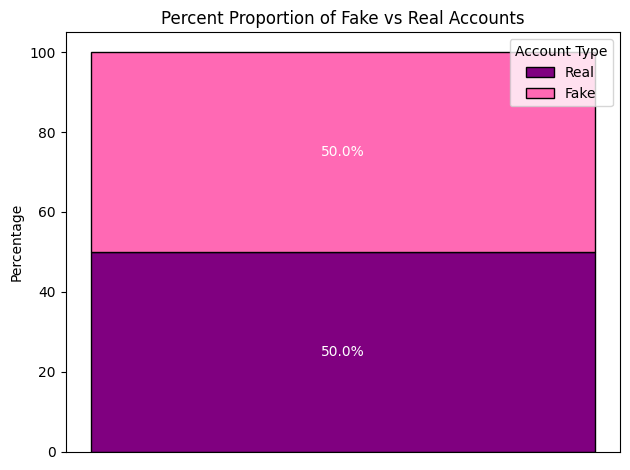

In [ ]:
#Bar Plot
x = ['Accounts']
real_percent = percentages.loc[percentages['label'] == 'Real', 'percent'].values[0]
fake_percent = percentages.loc[percentages['label'] == 'Fake', 'percent'].values[0]

fig, ax = plt.subplots()

#Bottom = Real
ax.bar(x, [real_percent], label='Real', color='purple', edgecolor='black', width=0.6)
# Top = Fake
ax.bar(x, [fake_percent], bottom=[real_percent], label='Fake', color='hotpink', edgecolor='black', width=0.6)

#Add Text Labels
ax.text(0, real_percent / 2, f"{real_percent:.1f}%", ha='center', va='center', color='white')
ax.text(0, real_percent + fake_percent / 2, f"{fake_percent:.1f}%", ha='center', va='center', color='white')
ax.set_ylabel("Percentage")
ax.set_title("Percent Proportion of Fake vs Real Accounts")
ax.set_xticks([])  
ax.legend(title="Account Type")

#Plot Display
plt.tight_layout()
plt.show()

There's an equal distribution of fake accounts and real accounts.

In [10]:
#Summary Statistics
print(instagram_data.describe(include="all"))

       profile_pic  username_with_numbers  wordcount_fullname  \
count   696.000000             696.000000          696.000000   
mean      0.711207               0.166609            1.475575   
std       0.453527               0.218964            1.076622   
min       0.000000               0.000000            0.000000   
25%       0.000000               0.000000            1.000000   
50%       1.000000               0.000000            1.000000   
75%       1.000000               0.330000            2.000000   
max       1.000000               0.920000           12.000000   

       fullname_with_numbers  fullname_is_username  bio_length  external_url  \
count             696.000000            696.000000  696.000000    696.000000   
mean                0.042170              0.035920   23.412356      0.113506   
std                 0.143664              0.186223   38.595721      0.317438   
min                 0.000000              0.000000    0.000000      0.000000   
25%           

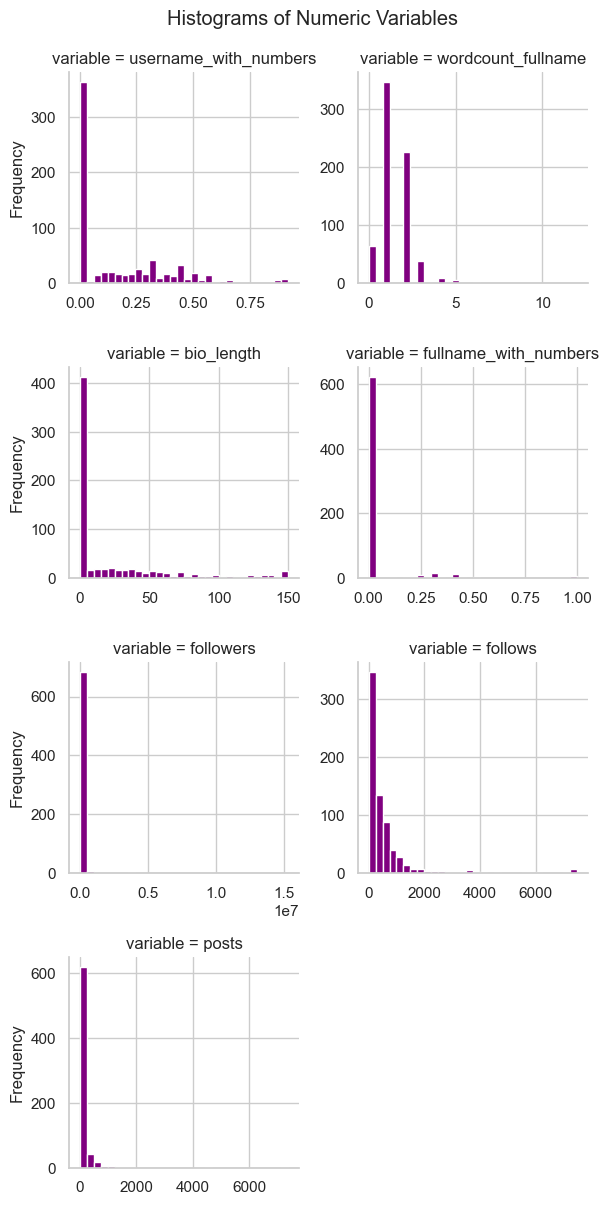

In [11]:
#Selected Columns for Histograms
cols = [
    "username_with_numbers",
    "wordcount_fullname",
    "bio_length",
    "fullname_with_numbers",
    "followers",
    "follows",
    "posts",
]

#Longer Format
numeric_long = instagram_data[cols].melt(
    var_name="variable",
    value_name="value"
)

#Plot Histograms
sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    numeric_long,
    col="variable",
    col_wrap=2,
    sharex=False,
    sharey=False
)
g.map(plt.hist, "value", bins=30, edgecolor="white", color="purple")

g.figure.suptitle("Histograms of Numeric Variables", y=1.02)
g.set_xlabels("")
g.set_ylabels("Frequency")

plt.show()

Most numerical variables are heavily-skewed.

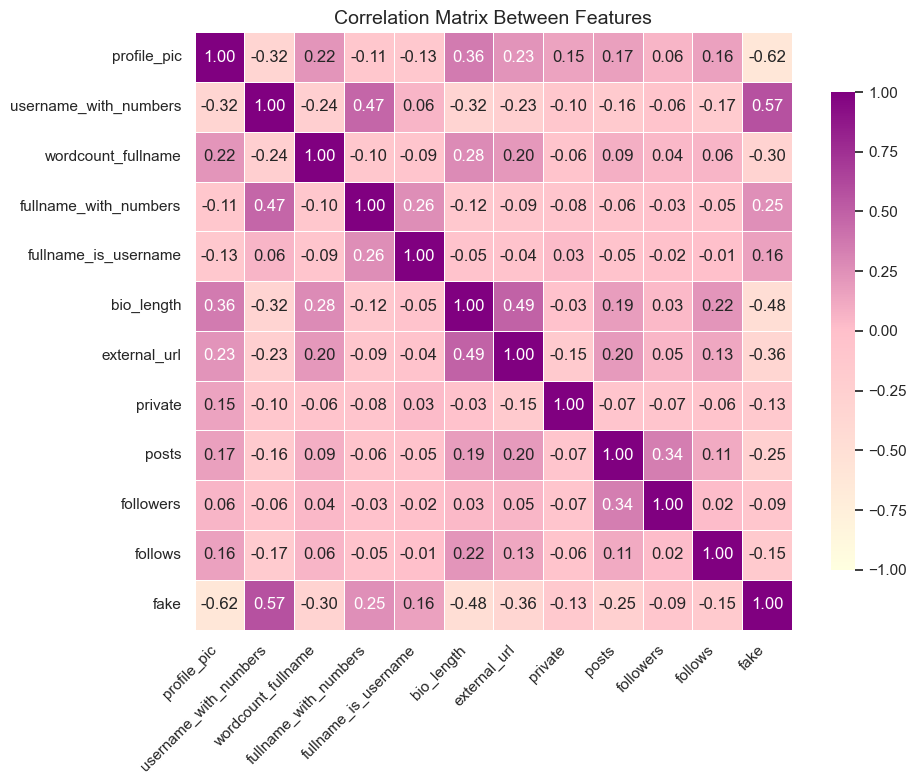

In [12]:
features_df = instagram_data.select_dtypes(include=[np.number])

#Compute correlation matrix 
cor_matrix = features_df.corr(method="pearson")
colors = ["lightyellow", "pink", "purple"]
cmap = LinearSegmentedColormap.from_list("yellow_pink_purple", colors)

#Plot correlation heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(
    cor_matrix,
    annot=True,          
    fmt=".2f",
    cmap=cmap,           
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix Between Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

There is a moderately positive correlation between fake accounts and username with numbers. There is a moderately negative correlation between fake accounts and profile pictures.

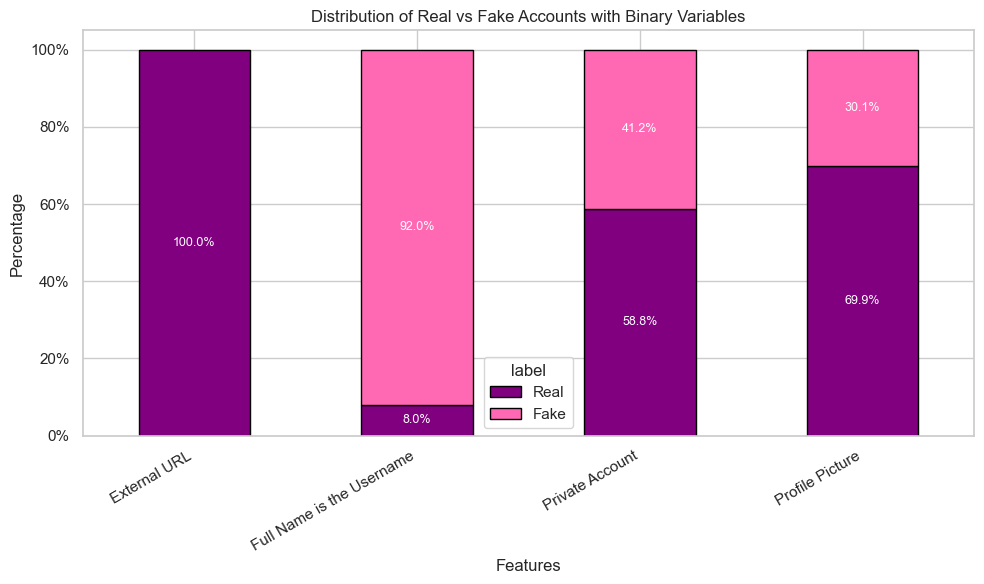

In [13]:
#Define binary features
binary_features = ["username_with_numbers", "external_url", "private", "profile_pic", "fullname_is_username"]

#Prepare long data
df = instagram_data.copy()

#Fake-Real Labels (1/0)
df["label"] = df["fake"].map({1: "Fake", 0: "Real"})

#Long Format
long_data = df.melt(
    id_vars=["label"],
    value_vars=binary_features,
    var_name="feature",
    value_name="value"
)

# Keep only rows where value == 1
long_data = long_data[long_data["value"] == 1]

#Rename
feature_labels = {
    "username_with_numbers": "Username has Numbers",
    "external_url": "External URL",
    "private": "Private Account",
    "profile_pic": "Profile Picture",
    "fullname_is_username": "Full Name is the Username"
}
long_data["feature"] = long_data["feature"].map(feature_labels)

#Count and compute percentage
plot_data = (
    long_data
    .groupby(["feature", "label"], as_index=False)
    .size()
    .rename(columns={"size": "n"})
)

#Percent within each feature
plot_data["percent"] = (
    plot_data.groupby("feature")["n"]
    .transform(lambda x: x / x.sum() * 100)
)

#Pivot for stacked bar plot
pivot = plot_data.pivot(
    index="feature",
    columns="label",
    values="percent"
).fillna(0)

pivot = pivot[["Real", "Fake"]]  

#Plot stacked percent bar chart
ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color={"Real": "purple", "Fake": "hotpink"},
    edgecolor="black"
)

ax.set_title("Distribution of Real vs Fake Accounts with Binary Variables")
ax.set_xlabel("Features")
ax.set_ylabel("Percentage")

#Rotate x-axis labels
plt.xticks(rotation=30, ha="right")

#Format y-axis as percentage (0–100 with %)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))

#Add percentage labels inside bars
for container in ax.containers:
    # For each segment in the stacked bars
    for bar in container:
        height = bar.get_height()
        if height > 0:
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_y() + height / 2
            ax.text(
                x, y,
                f"{height:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )

plt.tight_layout()
plt.show()

There were no fake accounts with external URL. There were more fake accounts with full name as their username and less fake accounts were set to private or had a picture in their profile.

## Logistic Regression ##

In [14]:
#Full Logistic Regression Model
full_model = smf.logit(
    formula="fake ~ profile_pic + fullname_is_username + external_url + private + "
            "username_with_numbers + fullname_with_numbers + wordcount_fullname + "
            "bio_length + posts + followers + follows",
    data=instagram_data
).fit()

print(full_model.summary())

         Current function value: 0.187783
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                   fake   No. Observations:                  696
Model:                          Logit   Df Residuals:                      684
Method:                           MLE   Df Model:                           11
Date:                Tue, 06 Jan 2026   Pseudo R-squ.:                  0.7291
Time:                        18:43:17   Log-Likelihood:                -130.70
converged:                      False   LL-Null:                       -482.43
Covariance Type:            nonrobust   LLR p-value:                9.746e-144
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.4420      1.536      4.194      0.000       3.431       9.453
profile_pic              -5.9940

C:\Users\Megan Huy\AppData\Roaming\Python\Python311\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\Megan Huy\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Megan Huy\AppData\Roaming\Python\Python311\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [15]:
#Odd Ratios for Full Model
ci = full_model.conf_int()  
ci_exp = np.exp(ci)
table = or_table = pd.DataFrame({
    "OR": np.exp(full_model.params),
    "Lower CI": ci_exp[0],
    "Upper CI": ci_exp[1],
    "p-value": full_model.pvalues
})

print(table)

                                 OR    Lower CI      Upper CI       p-value
Intercept              6.276374e+02   30.914787  1.274240e+04  2.744712e-05
profile_pic            2.493690e-03    0.000144  4.331855e-02  3.869244e-05
fullname_is_username   6.722580e+00    0.634666  7.120764e+01  1.135593e-01
external_url           2.264072e-13    0.000000           inf  9.999702e-01
private                3.087251e-01    0.160674  5.931962e-01  4.199036e-04
username_with_numbers  1.355886e+03  160.518905  1.145302e+04  3.480673e-11
fullname_with_numbers  1.235916e+01    0.036039  4.238391e+03  3.985503e-01
wordcount_fullname     7.363664e-01    0.518478  1.045822e+00  8.732765e-02
bio_length             9.887369e-01    0.978467  9.991143e-01  3.347788e-02
posts                  9.871733e-01    0.979789  9.946133e-01  7.520060e-04
followers              9.969393e-01    0.995799  9.980805e-01  1.509223e-07
follows                1.001139e+00    1.000700  1.001577e+00  3.559407e-07


C:\Users\Megan Huy\AppData\Roaming\Python\Python311\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


The likelihood of fake accounts is with features that have odds ratio > 1. This includes four features: full names with numbers, full name as the username, username with numbers, and follows. 

There is strong effect but variability is large for full name as username, full name with numbers, and username with numbers. There is a small effect for accounts with follows.

Using a significance level of α = 0.05, the model shows that profile picture, privacy, username with numbers, bio length, posts, followers, and followed accounts are all statistically significant predictors of the outcome.

In [16]:
#Gini Importance using Random Forest
X = instagram_data.drop(columns="fake")   
y = instagram_data["fake"]           

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=123
)
rf_model.fit(X, y)

var_imp_df = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)
print(var_imp_df)

                 Variable  Importance
9               followers    0.247097
8                   posts    0.227505
1   username_with_numbers    0.135682
5              bio_length    0.117369
0             profile_pic    0.103983
10                follows    0.091252
2      wordcount_fullname    0.042547
7                 private    0.013207
3   fullname_with_numbers    0.011370
6            external_url    0.007792
4    fullname_is_username    0.002196


We chose the five, top predictors for the reduced logistic regression model.

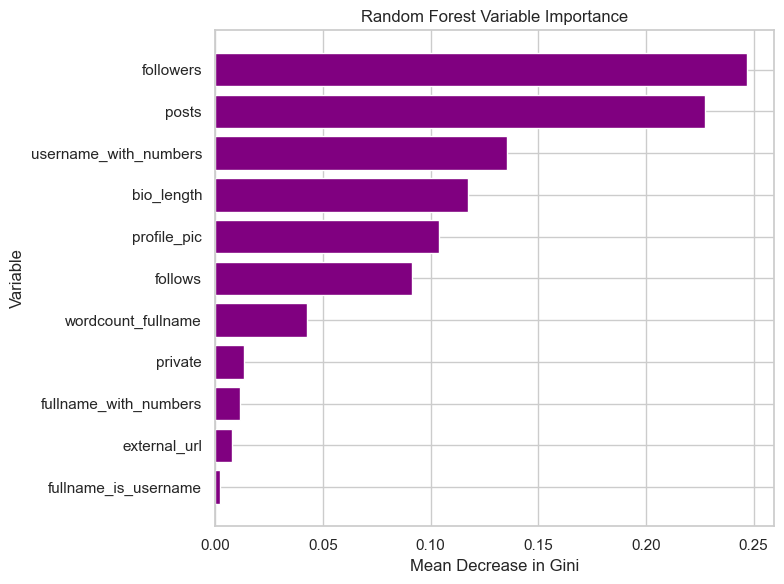

In [17]:
#Plot Variable Importance

plt.figure(figsize=(8, 6))
plt.barh(
    var_imp_df["Variable"],
    var_imp_df["Importance"],
    color="purple"
)
plt.gca().invert_yaxis()
plt.xlabel("Mean Decrease in Gini")
plt.ylabel("Variable")
plt.title("Random Forest Variable Importance")
plt.tight_layout()
plt.show()



In [18]:
#Reduced Model
reduced_model = smf.logit(
    formula="fake ~ followers + username_with_numbers + posts + profile_pic + bio_length",
    data=instagram_data
).fit()

print(reduced_model.summary())

Optimization terminated successfully.
         Current function value: 0.230266
         Iterations 18
                           Logit Regression Results                           
Dep. Variable:                   fake   No. Observations:                  696
Model:                          Logit   Df Residuals:                      690
Method:                           MLE   Df Model:                            5
Date:                Tue, 06 Jan 2026   Pseudo R-squ.:                  0.6678
Time:                        18:43:19   Log-Likelihood:                -160.27
converged:                       True   LL-Null:                       -482.43
Covariance Type:            nonrobust   LLR p-value:                5.321e-137
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.3971      0.853      5.154      0.000       2.725       6

C:\Users\Megan Huy\AppData\Roaming\Python\Python311\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\Megan Huy\AppData\Roaming\Python\Python311\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [19]:
#Odds Ratios for Reduced Model
ci = reduced_model.conf_int()  
ci_exp = np.exp(ci)
reduced_table = or_table = pd.DataFrame({
    "OR": np.exp(reduced_model.params),
    "Lower CI": ci_exp[0],
    "Upper CI": ci_exp[1],
    "p-value": reduced_model.pvalues
})

print(reduced_table)

                                OR    Lower CI     Upper CI       p-value
Intercept                81.215650   15.256634   432.335328  2.548227e-07
followers                 0.998598    0.997847     0.999349  2.567753e-04
username_with_numbers  1448.521380  235.845151  8896.575468  3.869562e-15
posts                     0.987150    0.980173     0.994176  3.515441e-04
profile_pic               0.008274    0.001613     0.042436  9.033178e-09
bio_length                0.984987    0.974855     0.995224  4.138084e-03


In [20]:
#AIC Comparison
print("Full Model AIC:", full_model.aic)
print("Reduced Model AIC:", reduced_model.aic)


Full Model AIC: 285.39426670254534
Reduced Model AIC: 332.5307256223304


Given AIC, we decided to keep the full model and use it for interpretation. 
The full model had a substantially lower AIC than the selected model, indicating that it provided a better overall fit to the data despite having more predictors.

We retained the full model for interpretation, as it captured more of the relevant relationships in the data than the reduced model. We will examine the odds ratios from the full model to quantify how changes in each predictor affected the odds of an account being classified as Fake, identifying which features increases those odds.

## Predictive Models ##

In [21]:
#Restore Data
train_data = pd.read_csv(r"C:\Users\Megan Huy\Documents\Instagram Project\instagram-data-train.csv")
test_data  = pd.read_csv(r"C:\Users\Megan Huy\Documents\Instagram Project\instagram-data-test.csv")

#Join Train and Test 
train_data["dataset"] = "train"
test_data["dataset"]  = "test"
instagram_data2 = pd.concat([train_data, test_data], ignore_index=True)

#Rename Variables
rename_map = {
    "profile pic": "profile_pic",
    "nums/length username": "username_with_numbers",
    "fullname words": "wordcount_fullname",
    "nums/length fullname": "fullname_with_numbers",
    "name==username": "fullname_is_username",
    "description length": "bio_length",
    "external URL": "external_url",
    "#posts": "posts",
    "#followers": "followers",
    "#follows": "follows",
}
instagram_data2 = instagram_data2.rename(columns=rename_map)

#Create Fake Label 0=no, 1=yes
instagram_data2["fake"] = instagram_data2["fake"].map({0: "no", 1: "yes"})

#Select Variables
model_vars = ["fake", "followers", "fullname_is_username", "username_with_numbers",
              "fullname_with_numbers", "follows", "dataset"]

instagram_data2 = instagram_data2[model_vars].dropna()

#Check if Fake Variable and Label are Correct
print(instagram_data2["fake"].value_counts(dropna=False))

fake
no     348
yes    348
Name: count, dtype: int64


In [22]:
#Train-Test Split
train_set, test_set = train_test_split(
    instagram_data2,
    test_size=0.20,        
    random_state=123,   
    stratify=instagram_data2["fake"]  
)

print("\nTest set class counts:")
print(test_set["fake"].value_counts())



Test set class counts:
fake
no     70
yes    70
Name: count, dtype: int64


10-fold CV ROC-AUC (train only):
  Random Forest: 0.953
  KNN:          0.887
  Logistic:     0.932

Random Forest
Confusion Matrix:
 [[63  7]
 [ 8 62]]

Classification Report:
               precision    recall  f1-score   support

           0      0.887     0.900     0.894        70
           1      0.899     0.886     0.892        70

    accuracy                          0.893       140
   macro avg      0.893     0.893     0.893       140
weighted avg      0.893     0.893     0.893       140

F1 (positive=1): 0.892
AUC: 0.957

KNN
Confusion Matrix:
 [[59 11]
 [10 60]]

Classification Report:
               precision    recall  f1-score   support

           0      0.855     0.843     0.849        70
           1      0.845     0.857     0.851        70

    accuracy                          0.850       140
   macro avg      0.850     0.850     0.850       140
weighted avg      0.850     0.850     0.850       140

F1 (positive=1): 0.851
AUC: 0.895

Logistic
Confusion Matrix:
 [[6

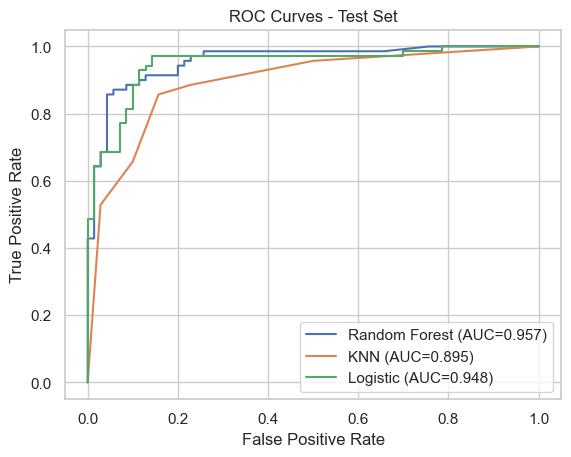


AUC - Random Forest: 0.9570408163265307
AUC - Logistic: 0.9475510204081633
AUC - KNN: 0.8947959183673471


In [23]:

#Prepare Data for Modeling
X_train = train_set.drop(columns=["fake", "dataset"])
y_train = train_set["fake"].map({"no": 0, "yes": 1})
X_test  = test_set.drop(columns=["fake", "dataset"])
y_test  = test_set["fake"].map({"no": 0, "yes": 1})


#Cross-validation Setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)


#Models (RF, KNN with Scaling, Logistic)
rf_model = RandomForestClassifier(n_estimators=500, random_state=123)

knn_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

log_model = LogisticRegression(max_iter=2000, solver="lbfgs")

#ROC-AUC Curve on Train Set
rf_cv_auc  = cross_val_score(rf_model,  X_train, y_train, cv=cv, scoring="roc_auc").mean()
knn_cv_auc = cross_val_score(knn_model, X_train, y_train, cv=cv, scoring="roc_auc").mean()
log_cv_auc = cross_val_score(log_model, X_train, y_train, cv=cv, scoring="roc_auc").mean()

print("10-fold CV ROC-AUC (train only):")
print(f"  Random Forest: {rf_cv_auc:.3f}")
print(f"  KNN:          {knn_cv_auc:.3f}")
print(f"  Logistic:     {log_cv_auc:.3f}")


#Fit on Train, evaluate on Test
models = {
    "Random Forest": rf_model,
    "KNN": knn_model,
    "Logistic": log_model
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

   
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)

    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "cm": cm,
        "f1": f1,
        "auc": auc,
        "y_proba": y_proba
    }

    print("\n" + "="*60)
    print(name)
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
    print(f"F1 (positive=1): {f1:.3f}")
    print(f"AUC: {auc:.3f}")


#ROC Curve on Test Set
plt.figure()

for name, out in results.items():
    fpr, tpr, _ = roc_curve(y_test, out["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={out['auc']:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set")
plt.legend(loc="lower right")
plt.show()


#Print AUCs
print("\nAUC - Random Forest:", results["Random Forest"]["auc"])
print("AUC - Logistic:", results["Logistic"]["auc"])
print("AUC - KNN:", results["KNN"]["auc"])


Random forest has the best AUC score of 0.957.